In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.data"

ratingsDf = pd.read_csv(
    url,
    sep='\t',
    names=['user_id', 'item_id', 'rating', 'timestamp']
)

In [4]:
#print(ratings_df.head())
print(ratingsDf)

       user_id  item_id  rating  timestamp
0          196      242       3  881250949
1          186      302       3  891717742
2           22      377       1  878887116
3          244       51       2  880606923
4          166      346       1  886397596
...        ...      ...     ...        ...
99995      880      476       3  880175444
99996      716      204       5  879795543
99997      276     1090       1  874795795
99998       13      225       2  882399156
99999       12      203       3  879959583

[100000 rows x 4 columns]


In [5]:
print(ratingsDf.shape)
print(ratingsDf.dtypes)
print(ratingsDf.describe())

(100000, 4)
user_id      int64
item_id      int64
rating       int64
timestamp    int64
dtype: object
            user_id        item_id         rating     timestamp
count  100000.00000  100000.000000  100000.000000  1.000000e+05
mean      462.48475     425.530130       3.529860  8.835289e+08
std       266.61442     330.798356       1.125674  5.343856e+06
min         1.00000       1.000000       1.000000  8.747247e+08
25%       254.00000     175.000000       3.000000  8.794487e+08
50%       447.00000     322.000000       4.000000  8.828269e+08
75%       682.00000     631.000000       4.000000  8.882600e+08
max       943.00000    1682.000000       5.000000  8.932866e+08


/tmp/ipykernel_156/4205334320.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratingsDf, palette='viridis')


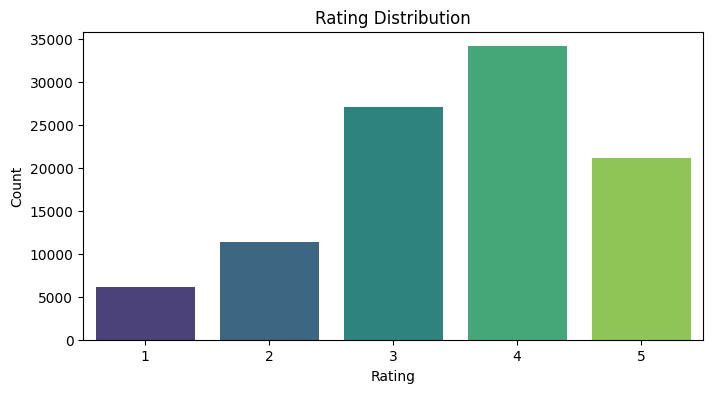

rating
4    34174
3    27145
5    21201
2    11370
1     6110
Name: count, dtype: int64
Mean rating: 3.53


In [6]:
plt.figure(figsize=(8,4))
sns.countplot(x='rating', data=ratingsDf, palette='viridis')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

print(ratingsDf['rating'].value_counts())
print(f"Mean rating: {ratingsDf['rating'].mean():.2f}")

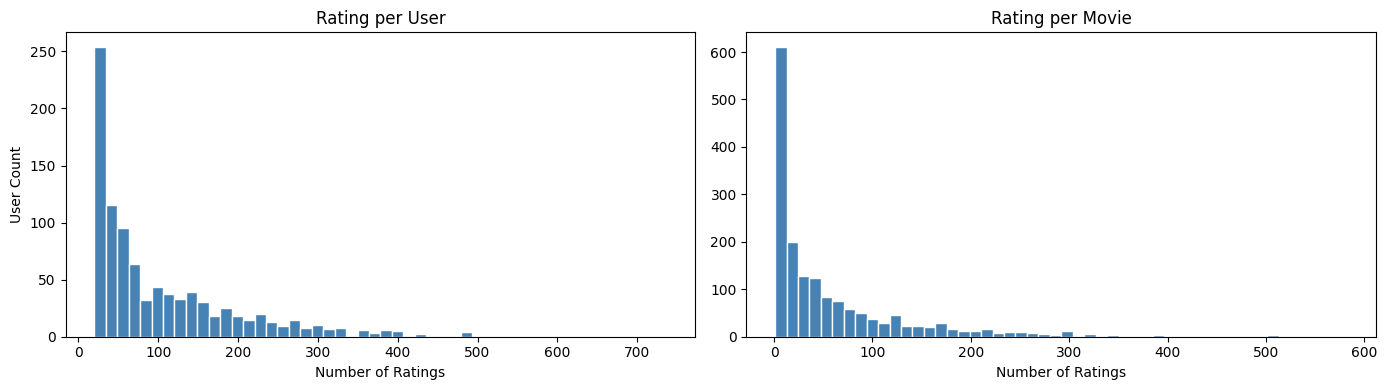

Users: 943
Movies: 1682
Most active user rated 737 movies
Most rated movie has 583 ratings


In [7]:
# User and Item Activity
ratingsPerUser = ratingsDf.groupby('user_id')['rating'].count()

ratingsPerMovie = ratingsDf.groupby('item_id')['rating'].count()

fig, axes = plt.subplots(1, 2, figsize=(14,4))

axes[0].hist(ratingsPerUser, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Rating per User')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('User Count')

axes[1].hist(ratingsPerMovie, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Rating per Movie')
axes[1].set_xlabel('Number of Ratings')

plt.tight_layout()
plt.show()

print(f"Users: {ratingsDf['user_id'].nunique()}")
print(f"Movies: {ratingsDf['item_id'].nunique()}")
print(f"Most active user rated {ratingsPerUser.max()} movies")
print(f"Most rated movie has {ratingsPerMovie.max()} ratings")


In [8]:
#Ratings over time
ratingsDf['timestamp'] = pd.to_datetime(ratingsDf['timestamp'], unit='s')
print(ratingsDf['timestamp'].dtype)

datetime64[ns]


/tmp/ipykernel_156/270738670.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ratingsDf.set_index('timestamp').resample('M')['rating'].count().plot(figsize=(12, 4), title='Rating Over Time', color='steelblue')


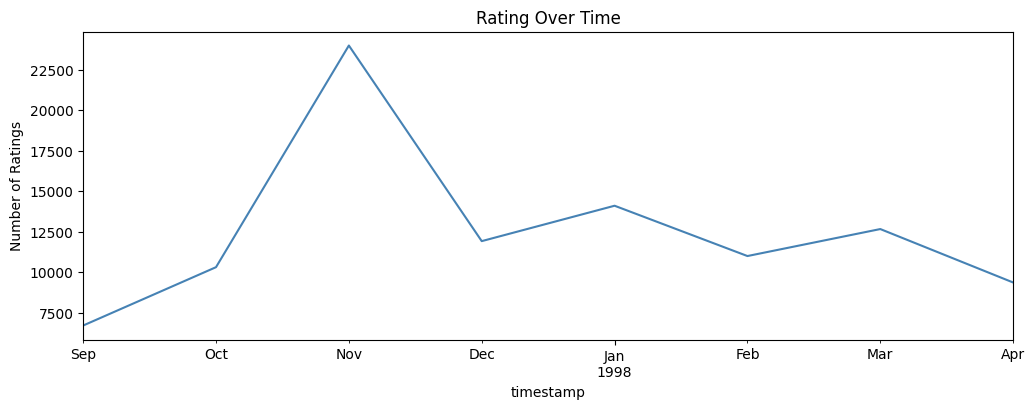

In [9]:
# Ratings Over Time
ratingsDf.set_index('timestamp').resample('M')['rating'].count().plot(figsize=(12, 4), title='Rating Over Time', color='steelblue')
#plt.xlabel('Date')
plt.ylabel('Number of Ratings')
plt.show()

In [10]:
#Sparsity of matrix
nUsers = ratingsDf['user_id'].nunique()
nMovies = ratingsDf['item_id'].nunique()
sparsity = 1 - (len(ratingsDf) / (nUsers * nMovies))
print(f"Matrix sparsity: {sparsity:.2%}")

Matrix sparsity: 93.70%


In [11]:
#Top moves by ave rating
movieStats = ratingsDf.groupby('item_id')['rating'].agg(['mean', 'count'])
topMovies = movieStats[movieStats['count'] >= 50].sort_values('mean', ascending=False).head(10)
print(topMovies)

             mean  count
item_id                 
408      4.491071    112
318      4.466443    298
169      4.466102    118
483      4.456790    243
114      4.447761     67
64       4.445230    283
603      4.387560    209
12       4.385768    267
50       4.358491    583
178      4.344000    125


In [15]:
# Do power users rate differently from casual users?
ratingsPerUser = ratingsDf.groupby('user_id')['rating'].agg(['count', 'mean'])
ratingsPerUser['user_type'] = pd.cut(ratingsPerUser['count'],
                                     bins=[0,20,100,np.inf],
                                     labels=['Casual','Regular','Power'])
ratingsPerUser.groupby('user_type')['mean'].describe()

#mean is the average rating across the user class
#std is how spread out tge various ratings are to each other for the user class
#min is the lowest per-user average rating in that particular user class

/tmp/ipykernel_156/2149446317.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ratingsPerUser.groupby('user_type')['mean'].describe()


,count,mean,std,min,25%,50%,75%,max
user_type,,,,,,,,
Casual,32.0,3.501562,0.545729,2.050000,3.28750,3.500000,3.762500,4.450000
Regular,550.0,3.628817,0.450516,2.164706,3.36000,3.663978,3.919730,4.869565
Power,361.0,3.533975,0.421196,1.491954,3.31338,3.572464,3.811024,4.571429


/tmp/ipykernel_156/473313192.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  temporal = ratingsDf.set_index('timestamp').resample('M')['rating'].agg(['mean','count'])


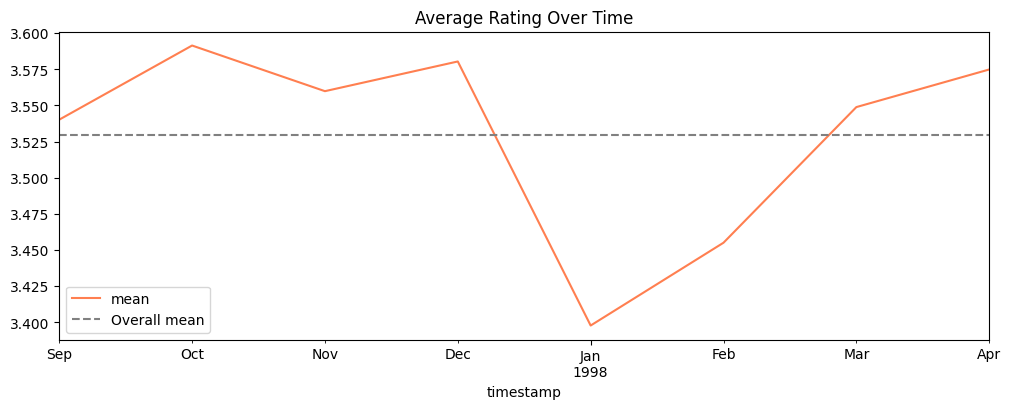

In [17]:
# Temporal drift - tests whether users tastes vary over time
temporal = ratingsDf.set_index('timestamp').resample('M')['rating'].agg(['mean','count'])
temporal['mean'].plot(figsize=(12,4), title='Average Rating Over Time', color='coral')
plt.axhline(ratingsDf['rating'].mean(), linestyle='--', color='grey', label='Overall mean')
plt.legend()